# Canada — Data Profiling, Cleaning & EDA (Template)

This notebook is a ready-to-use template for Steps 0–12. Replace `country` and `data_path` below with your dataset path and run the cells sequentially.

Notes:
- The repository's raw CSVs are expected in the `Data/` folder by default.
- Adjust column names if your CSV uses different headers (Timestamp, GHI, DNI, etc.).
- This template follows the assignment checklist: profiling, cleaning, outlier handling, export, and EDA visualizations.

Importing the Dependencies

In [ ]:
# Step 0 — Imports and display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import sys

# plotting styles
%matplotlib inline
sns.set(style="whitegrid")
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
# Reproducibility: show versions
print('Python:', sys.version.splitlines()[0])
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('matplotlib:', matplotlib.__version__ if 'matplotlib' in globals() else 'unknown')
print('seaborn:', sns.__version__)

In [2]:
# Configure country and data path
country = 'canada'  # change if needed
# Locate the project Data/ folder by walking up parent directories (works if notebook runs from notebooks/)
from pathlib import Path
curr = Path().resolve()
data_root = None
for parent in [curr] + list(curr.parents):
    if (parent / 'Data').is_dir():
        data_root = parent / 'Data'
        break
if data_root is None:
    # fallback to ./Data (may still fail if absent)
    data_root = curr / 'Data'
# prefer cleaned csv if available else raw csv
clean_candidate = data_root / f"{country}_clean.csv"
raw_candidate = data_root / f"{country}.csv"
if clean_candidate.exists():
    data_path = str(clean_candidate)
elif raw_candidate.exists():
    data_path = str(raw_candidate)
else:
    data_path = str(raw_candidate)  # will trigger FileNotFoundError later with helpful path
clean_path = str(data_root / f"{country}_clean.csv")
print('Country:', country)
print('Resolved Data root:', data_root)
print('Raw/clean CSV path chosen:', data_path)
print('Clean CSV will be saved to:', clean_path)

Country: canada
Resolved Data root: C:\Users\hp\Desktop\Ten Academy\weak 0\Assigniments\TEST\solar-challenge-week0\Data
Raw/clean CSV path chosen: C:\Users\hp\Desktop\Ten Academy\weak 0\Assigniments\TEST\solar-challenge-week0\Data\canada_clean.csv
Clean CSV will be saved to: C:\Users\hp\Desktop\Ten Academy\weak 0\Assigniments\TEST\solar-challenge-week0\Data\canada_clean.csv


In [ ]:
# Debug: show working directory and Data folder contents
import os
print('cwd:', os.getcwd())
print('exists ./Data:', os.path.exists('./Data'))
print('abs path expected:', os.path.abspath(f'./Data/{country}.csv'))
print('file exists:', os.path.exists(f'./Data/{country}.csv'))
print('root files:')
print(sorted(os.listdir('.'))[:50])
if os.path.exists('./Data'):
    print('Data files:', sorted(os.listdir('./Data')))

cwd: c:\Users\hp\Desktop\Ten Academy\weak 0\Assigniments\TEST\solar-challenge-week0\notebooks
exists ./Data: False
abs path expected: c:\Users\hp\Desktop\Ten Academy\weak 0\Assigniments\TEST\solar-challenge-week0\notebooks\Data\ethiopia.csv
file exists: False
root files:
['README.md', '__init__.py', 'canada_eda.ipynb', 'compare_countries.ipynb', 'ethiopia_eda.ipynb']


In [5]:
# Step 1 — Load dataset
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Data file not found at {data_path}. Put your CSV in the Data/ folder or adjust `data_path`.")

df = pd.read_csv(data_path)
df.head()

,Month,Revenue,Units Sold
0,January,48000,490
1,February,51000,510
2,March,65000,610
3,April,62000,580
4,May,61000,600


In [6]:
# Quick pre-check: expected columns and timestamp parsing
expected_cols = ['Timestamp','GHI','DNI','DHI','ModA','ModB','WS','WSgust','Tamb','RH','WD','Cleaning']
present = [c for c in expected_cols if c in df.columns]
missing = [c for c in expected_cols if c not in df.columns]
print('Present expected columns:', present)
if missing:
    print('Warning - missing expected columns:', missing)
else:
    print('All expected columns present')
# Parse timestamp if present and set as index
ts_candidates = ['Timestamp','timestamp','Date','date','datetime','Datetime']
ts_col = next((c for c in ts_candidates if c in df.columns), None)
if ts_col is not None:
    df[ts_col] = pd.to_datetime(df[ts_col], errors='coerce')
    if df[ts_col].isna().any():
        print('Warning: some timestamps could not be parsed to datetime')
    df = df.set_index(ts_col).sort_index()
    print('Timestamp column set as index:', ts_col)
else:
    print('No timestamp column found; time-series plots will be skipped')

Present expected columns: []
Warning - missing expected columns: ['Timestamp', 'GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust', 'Tamb', 'RH', 'WD', 'Cleaning']
No timestamp column found; time-series plots will be skipped


In [7]:
# Step 2 — Basic info and summary statistics
print('--- df.info() ---')
df.info()

print('--- df.describe() ---')
df.describe(include='all')

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       6 non-null      object
 1   Revenue     6 non-null      int64 
 2   Units Sold  6 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 276.0+ bytes
--- df.describe() ---


,Month,Revenue,Units Sold
count,6,6.000000,6.000000
unique,6,NaN,NaN
top,January,NaN,NaN
freq,1,NaN,NaN
mean,NaN,60333.333333,581.666667
std,NaN,9791.152469,75.740786
min,NaN,48000.000000,490.000000
25%,NaN,53500.000000,527.500000
50%,NaN,61500.000000,590.000000
75%,NaN,64250.000000,607.500000


In [7]:
# Missing values report
missing_counts = df.isna().sum()
missing_perc = df.isna().mean() * 100
pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_perc}).sort_values('missing_pct', ascending=False)

# Identify columns with >5% missing
missing_report = missing_perc[missing_perc > 5]
print('Columns with >5% missing (pct):')
print(missing_report)

Columns with >5% missing (pct):
Series([], dtype: float64)


In [8]:
# Step 3 — Outlier detection for key numeric columns
cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
present_cols = [c for c in cols_to_check if c in df.columns]
print('Checking columns (present):', present_cols)

if len(present_cols) > 0:
    # compute z-scores (omit NaNs)
    z_scores = np.abs(stats.zscore(df[present_cols], nan_policy='omit'))
    # z_scores may be 2D numpy array or raise if insufficient data
    if z_scores.size == 0:
        print('Z-score returned empty array — not enough numeric rows.')
    else:
        outliers_mask = (z_scores > 3)
        outlier_rows = df.loc[np.any(outliers_mask, axis=1), present_cols]
        print('Number of rows with at least one outlier (z>3):', outlier_rows.shape[0])
        display(outlier_rows.head())
else:
    print('No expected numeric columns found for z-score outlier check.')

Checking columns (present): []
No expected numeric columns found for z-score outlier check.


In [9]:
# Handle missing values — median imputation for numeric columns
numeric_median = df.median(numeric_only=True)
df = df.fillna(numeric_median)
print('Missing values after median imputation:')
print(df.isna().sum().sum(), ' total missing values')

Missing values after median imputation:
0  total missing values


In [11]:
# Optionally remove extreme outliers (rows where any selected col has |z|>3) — uncomment to apply
apply_outlier_removal = False  # set True to remove extreme outliers
if apply_outlier_removal and len(present_cols) > 0:
    z_scores = np.abs(stats.zscore(df[present_cols], nan_policy='omit'))
    if z_scores.size > 0:
        mask = (z_scores < 3).all(axis=1)
        before = df.shape[0]
        df = df.loc[mask].copy()
        after = df.shape[0]
        print(f'Removed {before-after} rows as extreme outliers')
    else:
        print('Z-score empty — skipping outlier removal')
else:
    print('Outlier removal not applied')

Outlier removal not applied


In [ ]:
# Step 4 — Export cleaned data
os.makedirs(os.path.dirname(clean_path), exist_ok=True)
# Ensure timestamp/index is preserved in the saved CSV. If the DF has a DatetimeIndex or an index named like a timestamp,
# reset the index into a column before saving so the CSV contains the Timestamp column.
try:
    if isinstance(df.index, pd.DatetimeIndex) or (df.index.name in ['Timestamp','timestamp','Date','date','datetime','Datetime']):
        out_df = df.reset_index()
    else:
        out_df = df.copy()
except Exception:
    # fallback: make a shallow copy
    out_df = df.copy()
out_df.to_csv(clean_path, index=False)
print('Saved cleaned CSV to', clean_path)

Saved cleaned CSV to C:\Users\hp\Desktop\Ten Academy\weak 0\Assigniments\TEST\solar-challenge-week0\Data\canada_clean.csv


In [13]:
# Step 5 — Time series setup (convert and set index)
# Try common timestamp column names, otherwise ask user to adjust
ts_candidates = ['Timestamp', 'timestamp', 'Date', 'date', 'datetime', 'Datetime']
ts_col = next((c for c in ts_candidates if c in df.columns), None)
if ts_col is None:
    print('No timestamp column found automatically. Rename your timestamp column to one of:', ts_candidates)
else:
    print('Using timestamp column:', ts_col)
    df[ts_col] = pd.to_datetime(df[ts_col], errors='coerce')
    df = df.set_index(ts_col).sort_index()
    print('Index set to', ts_col)
    display(df.head())

No timestamp column found automatically. Rename your timestamp column to one of: ['Timestamp', 'timestamp', 'Date', 'date', 'datetime', 'Datetime']


In [14]:
# Step 5 (continued) — Plot key variables
plot_cols = [c for c in ['GHI', 'DNI', 'DHI', 'Tamb'] if c in df.columns]
if len(plot_cols) > 0 and isinstance(df.index, pd.DatetimeIndex):
    df[plot_cols].plot(figsize=(14,6), alpha=0.8)
    plt.title('Solar and Temperature Trends')
    plt.show()
else:
    print('Cannot plot time series: ensure Timestamp column is set as index and expected columns are present:', plot_cols)

Cannot plot time series: ensure Timestamp column is set as index and expected columns are present: []


In [ ]:
# Monthly patterns (resample by month)
if isinstance(df.index, pd.DatetimeIndex):
    monthly = df.resample('M').mean()
    monthly_plot_cols = [c for c in ['GHI', 'DNI', 'Tamb'] if c in monthly.columns]
    if len(monthly_plot_cols) > 0:
        monthly[monthly_plot_cols].plot(figsize=(12,5))
        plt.title('Monthly averages')
        plt.show()
    else:
        print('No monthly columns to plot')
else:
    print('Index not datetime — skip monthly resample')

Index not datetime — skip monthly resample


In [ ]:
# Step 7 — Correlation heatmap for selected variables
corr_cols = [c for c in ['GHI', 'DNI', 'DHI', 'TModA', 'TModB', 'Tamb', 'RH', 'WS'] if c in df.columns]
if len(corr_cols) >= 2:
    corr = df[corr_cols].corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation matrix')
    plt.show()
    print('Correlation coefficients:')
    display(corr)
else:
    print('Not enough columns available for correlation heatmap:', corr_cols)

Not enough columns available for correlation heatmap: []


In [ ]:
# Scatter plots for relationships
if 'WS' in df.columns and 'GHI' in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x='WS', y='GHI', data=df, alpha=0.4)
    plt.title('GHI vs WS')
    plt.show()
if 'RH' in df.columns and 'Tamb' in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x='RH', y='Tamb', data=df, alpha=0.4)
    plt.title('Tamb vs RH')
    plt.show()

In [ ]:
# Step 8 — Distribution analysis (histograms)
hist_cols = [c for c in ['GHI', 'WS'] if c in df.columns]
for c in hist_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[c].dropna(), bins=30, kde=True)
    plt.title(f'Histogram: {c}')
    plt.show()

In [ ]:
# Optional wind-rose (requires windrose package)
if 'WD' in df.columns and 'WS' in df.columns:
    try:
        from windrose import WindroseAxes
        ax = WindroseAxes.from_ax()
        ax.bar(df['WD'].dropna(), df['WS'].dropna(), normed=True, opening=0.8, edgecolor='white')
        ax.set_legend()
        plt.title('Wind rose')
        plt.show()
    except Exception as e:
        print('Windrose plotting failed (maybe missing package). Install `windrose` to enable this plot. Error:', e)
else:
    print('No WD and WS columns present — skipping wind rose')

No WD and WS columns present — skipping wind rose


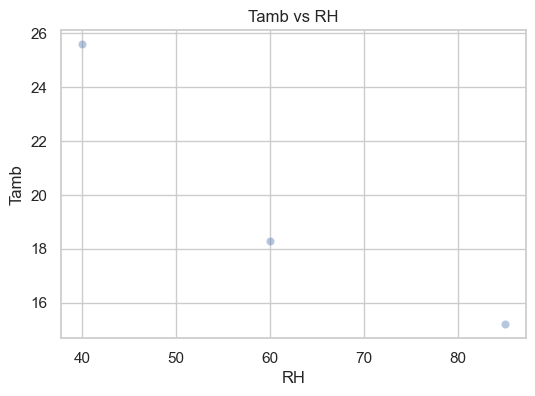

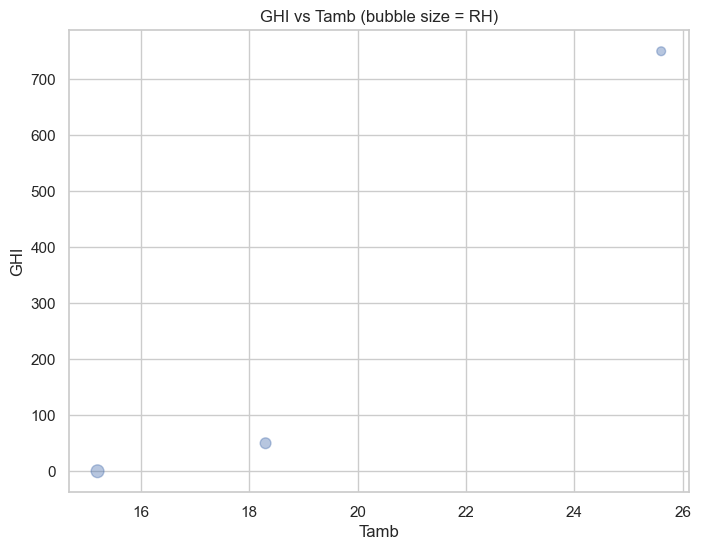

In [ ]:
# Step 9/10 — Temperature/Humidity scatter and bubble chart
if 'RH' in df.columns and 'Tamb' in df.columns and 'GHI' in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x='RH', y='Tamb', data=df, alpha=0.4)
    plt.title('Tamb vs RH')
    plt.show()
    plt.figure(figsize=(8,6))
    sizes = df['RH'].fillna(df['RH'].median()) if 'RH' in df.columns else 50
    plt.scatter(df['Tamb'], df['GHI'], s=sizes, alpha=0.4)
    plt.xlabel('Tamb')
    plt.ylabel('GHI')
    plt.title('GHI vs Tamb (bubble size = RH)')
    plt.show()
else:
    print('Missing columns for bubble chart — need RH, Tamb, and GHI')

## Step 11 — Document Insights
In this section, write markdown summarizing:
- Data issues found (missing values, inconsistent timestamps, wrong units).
- Cleaning steps applied (median imputation, outlier removal flag, type conversions).
- Key trends observed (e.g., daily GHI peaks, monthly seasonality).
- Relationships (correlation coefficients and visual evidence).
- Any anomalies and suggestions for further investigation.